In [1]:
# ===== درس ۸: Matplotlib پایه =====

# ۱. اتصال Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ۲. تعریف مسیرهای پروژه با pathlib
from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/scRNA_project")
LESSON = PROJECT / "lesson08"

CODE = LESSON / "code"
NOTES = LESSON / "notes"
OUTPUT = LESSON / "output"

# ۳. ساخت پوشه‌های همین درس
for folder in [CODE, NOTES, OUTPUT]:
    folder.mkdir(parents=True, exist_ok=True)
    print("آماده شد:", folder)

# ۴. نصب و بارگذاری Scanpy + NumPy + Pandas + Matplotlib + دیتاست PBMC-3k
!pip install scanpy -q
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

adata = sc.datasets.pbmc3k()

Mounted at /content/drive
آماده شد: /content/drive/MyDrive/scRNA_project/lesson08/code
آماده شد: /content/drive/MyDrive/scRNA_project/lesson08/notes
آماده شد: /content/drive/MyDrive/scRNA_project/lesson08/output
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

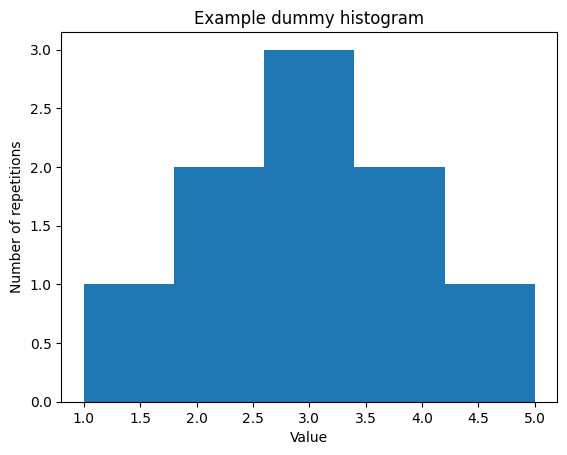

In [16]:
# ۵. هیستوگرام روی داده‌ی ساختگی (فقط برای یادگیری مفهوم)
sample_data = [1, 2, 2, 3, 3, 3, 4, 4, 5]

plt.hist(sample_data, bins=5)
plt.title("Example dummy histogram")
plt.xlabel("Value")
plt.ylabel("Number of repetitions")
plt.show()

In [3]:
# ۶. ساخت دو معیار واقعی QC: n_genes و total_counts
n_genes_per_cell = np.asarray((adata.X > 0).sum(axis=1)).flatten()
total_counts_per_cell = np.asarray(adata.X.sum(axis=1)).flatten()

adata.obs["n_genes"] = n_genes_per_cell
adata.obs["total_counts"] = total_counts_per_cell

print(adata.obs.head())

                  n_genes  total_counts
index                                  
AAACATACAACCAC-1      781        2421.0
AAACATTGAGCTAC-1     1352        4903.0
AAACATTGATCAGC-1     1131        3149.0
AAACCGTGCTTCCG-1      960        2639.0
AAACCGTGTATGCG-1      522         981.0


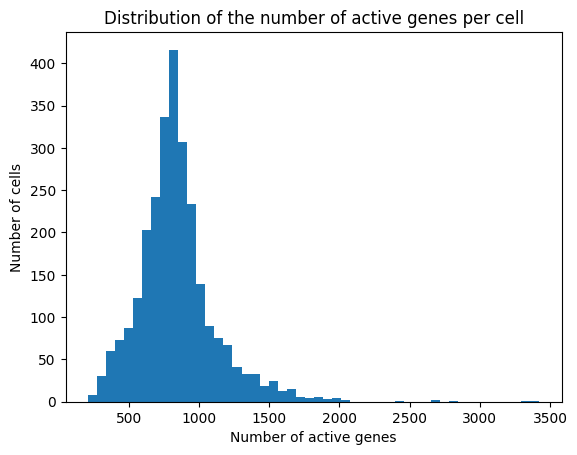

In [15]:
# ۷. هیستوگرام واقعی اول: تعداد ژن فعال در هر سلول
plt.hist(adata.obs["n_genes"], bins=50)
plt.title("Distribution of the number of active genes per cell")
plt.xlabel("Number of active genes")
plt.ylabel("Number of cells")
plt.show()

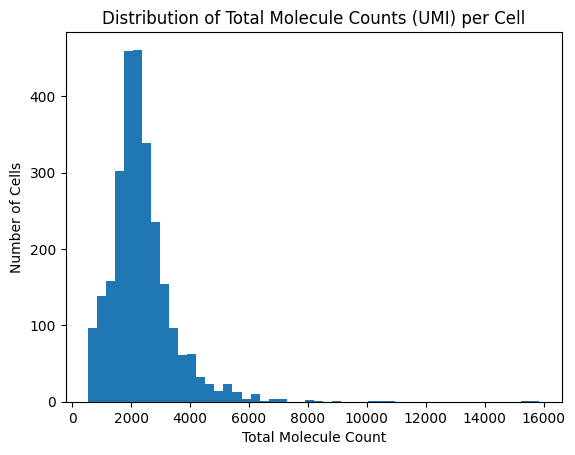

In [14]:
# ۸. هیستوگرام واقعی دوم: تعداد کل مولکول در هر سلول
plt.hist(adata.obs["total_counts"], bins=50)
plt.title("Distribution of Total Molecule Counts (UMI) per Cell")
plt.xlabel("Total Molecule Count")
plt.ylabel("Number of Cells")
plt.show()

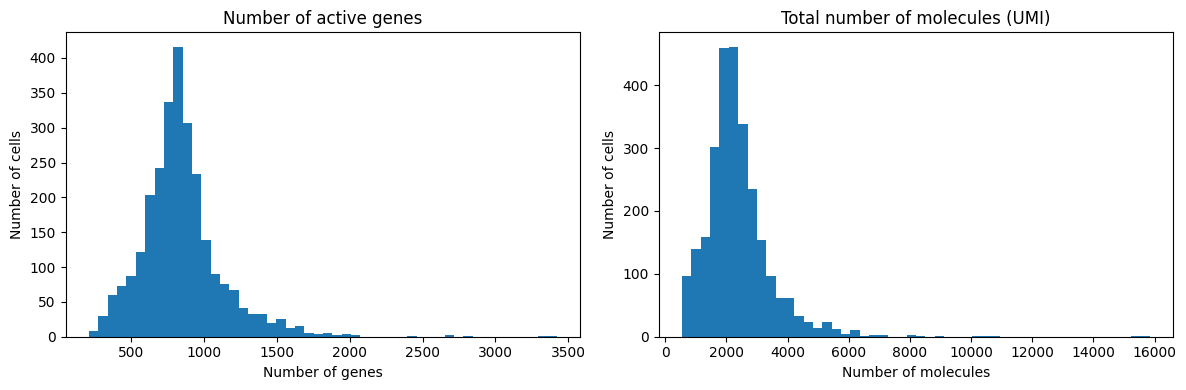

In [13]:
# ۹. نسخه‌ی حرفه‌ای‌تر: هر دو هیستوگرام کنار هم، در یک شکل
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(adata.obs["n_genes"], bins=50)
axes[0].set_title("Number of active genes")
axes[0].set_xlabel("Number of genes")
axes[0].set_ylabel("Number of cells")

axes[1].hist(adata.obs["total_counts"], bins=50)
axes[1].set_title("Total number of molecules (UMI)")
axes[1].set_xlabel("Number of molecules")
axes[1].set_ylabel("Number of cells")

plt.tight_layout()
plt.show()

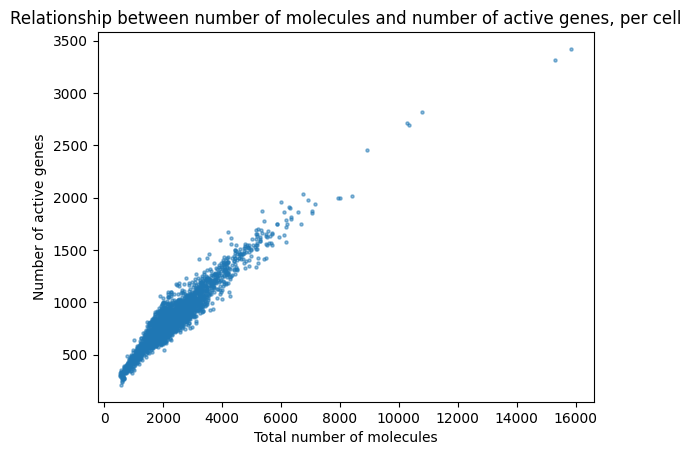

In [12]:
# ۱۰. نمودار پراکندگی: رابطه‌ی بین n_genes و total_counts
plt.scatter(adata.obs["total_counts"], adata.obs["n_genes"], s=5, alpha=0.5)
plt.title("Relationship between number of molecules and number of active genes, per cell")
plt.xlabel("Total number of molecules")
plt.ylabel("Number of active genes")
plt.show()